# Demo: 14 xác suất bệnh cho một ảnh X-quang

**Nghiên cứu, không dùng để chẩn đoán.** Notebook nạp `best.pt` (DenseNet-121, baseline BCE), áp dụng nhiệt độ T và ngưỡng riêng từng bệnh do Khối E và D tìm trên tập validation.

**Cách dùng:** chạy lần lượt từ trên xuống. Không cần bật GPU.

**Lưu ý quan trọng:** các ngưỡng được chọn trên xác suất **gốc** `sigmoid(z)`, nên quyết định so ngưỡng với xác suất gốc. Xác suất đã hiệu chỉnh (chia T) chỉ để hiển thị.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CKPT = '/content/drive/MyDrive/CXR_Project/best.pt'
VAL_CSV = '/content/drive/MyDrive/CXR_Project/data/val.csv'

Mounted at /content/drive


## 1. Hằng số và hàm

In [ ]:
import numpy as np

DISEASES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia",
]

# F1 optimal thresholds (threshold_eval.xlsx), tuned on the validation set
# on the UNCALIBRATED probability sigmoid(z). Compare them with that probability.
THRESHOLDS = {
    "Atelectasis": 0.235, "Cardiomegaly": 0.188, "Effusion": 0.201,
    "Infiltration": 0.224, "Mass": 0.185, "Nodule": 0.204,
    "Pneumonia": 0.061, "Pneumothorax": 0.142, "Consolidation": 0.148,
    "Edema": 0.086, "Emphysema": 0.161, "Fibrosis": 0.072,
    "Pleural_Thickening": 0.150, "Hernia": 0.035,
}

# Per finding temperatures (calibration.xlsx), fitted on the validation set
TEMPERATURES = {
    "Atelectasis": 1.075627, "Cardiomegaly": 1.074076, "Effusion": 1.157054,
    "Infiltration": 1.004973, "Mass": 1.097634, "Nodule": 1.007098,
    "Pneumonia": 0.983853, "Pneumothorax": 1.070431, "Consolidation": 1.066427,
    "Edema": 1.113588, "Emphysema": 1.015247, "Fibrosis": 1.094116,
    "Pleural_Thickening": 1.007036, "Hernia": 1.032988,
}

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def load_image(path):
    # Same preprocessing as training: gray, 224x224, divide by 255, 3 channels, ImageNet statistics
    from PIL import Image
    img = Image.open(path).convert("L").resize((224, 224))
    x = np.asarray(img, dtype=np.float32) / 255.0
    x = np.repeat(x[None], 3, axis=0)
    return (x - MEAN) / STD


def decide(logits):
    """Turn 14 logits into raw probabilities, calibrated probabilities and yes/no decisions."""
    z = np.asarray(logits, dtype=np.float64)
    temps = np.array([TEMPERATURES[d] for d in DISEASES])
    thresholds = np.array([THRESHOLDS[d] for d in DISEASES])
    p_raw = sigmoid(z)
    p_cal = sigmoid(z / temps)
    # The thresholds were tuned on p_raw, so the decision must use p_raw.
    # This is the same as comparing p_cal with sigmoid(logit(t) / T).
    positive = p_raw >= thresholds
    return p_raw, p_cal, positive


def load_model(ckpt_path):
    import torch
    import torch.nn as nn
    from torchvision import models
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, len(DISEASES))
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(ckpt["model"])          # best.pt stores a dict, the weights are under "model"
    model.eval()
    return model


def predict(image_path, model):
    import torch
    x = torch.from_numpy(load_image(image_path)).unsqueeze(0)
    with torch.no_grad():
        logits = model(x).squeeze(0).numpy()
    p_raw, p_cal, positive = decide(logits)
    order = np.argsort(-p_cal)
    print(f"\n{'Finding':<22}{'Calibrated p':<14}{'Threshold':<11}{'Decision':<10}")
    print("-" * 57)
    for i in order:
        d = DISEASES[i]
        mark = "Positive" if positive[i] else "Negative"
        print(f"{d:<22}{p_cal[i]:<14.4f}{THRESHOLDS[d]:<11.3f}{mark:<10}")
    print("\nResearch prototype, not for diagnosis. Thresholds favour recall on rare findings, so expect many false alarms.")
    return p_cal, positive


## 2. Nạp mô hình

In [ ]:
import torch

model = load_model(CKPT)
print('Kích thước đầu ra:', model(torch.zeros(1, 3, 224, 224)).shape)   # phải là [1, 14]

Kích thước đầu ra: torch.Size([1, 14])


In [ ]:
import os
import kagglehub

root = kagglehub.dataset_download('khanfashee/nih-chest-x-ray-14-224x224-resized')   # đã tải rồi nên trả về ngay
print('Bộ dữ liệu nằm ở:', root)

KAGGLE_LINK = '/kaggle/input/nih-chest-x-ray-14-224x224-resized'
if not os.path.exists(KAGGLE_LINK):
    os.makedirs(os.path.dirname(KAGGLE_LINK), exist_ok=True)
    os.symlink(root, KAGGLE_LINK)
print('Đường dẫn trong CSV dùng được:', os.path.exists(KAGGLE_LINK + '/images-224/images-224'))

Using Colab cache for faster access to the 'nih-chest-x-ray-14-224x224-resized' dataset.
Bộ dữ liệu nằm ở: /kaggle/input/nih-chest-x-ray-14-224x224-resized
Đường dẫn trong CSV dùng được: True


## 3. Dự đoán trên một ảnh của tập validation (có nhãn thật để so sánh)

Đổi `random_state` để lấy ảnh khác. Đây là ảnh minh họa, không dùng để đánh giá độ chính xác.

Using Colab cache for faster access to the 'nih-chest-x-ray-14-224x224-resized' dataset.


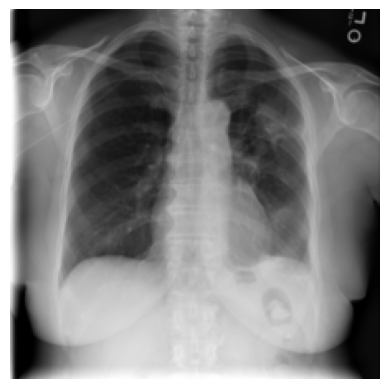

Bệnh có thật trong ảnh: ['Effusion', 'Nodule']

Finding               Calibrated p  Threshold  Decision  
---------------------------------------------------------
Nodule                0.1648        0.204      Negative  
Mass                  0.1615        0.185      Negative  
Pneumothorax          0.1508        0.142      Negative  
Pleural_Thickening    0.1222        0.150      Negative  
Infiltration          0.0911        0.224      Negative  
Effusion              0.0797        0.201      Negative  
Atelectasis           0.0405        0.235      Negative  
Consolidation         0.0302        0.148      Negative  
Fibrosis              0.0218        0.072      Negative  
Emphysema             0.0140        0.161      Negative  
Pneumonia             0.0052        0.061      Negative  
Edema                 0.0016        0.086      Negative  
Cardiomegaly          0.0012        0.188      Negative  
Hernia                0.0008        0.035      Negative  

Research prototype, not

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Cột path trỏ vào /kaggle/input/..., ảnh chỉ có sau khi tải bộ dữ liệu
kagglehub.dataset_download('khanfashee/nih-chest-x-ray-14-224x224-resized')
val = pd.read_csv(VAL_CSV)
disease = 'Effusion'          # đổi thành bệnh khác: 'Cardiomegaly', 'Pneumothorax', ...
row = val[val[disease] == 1].sample(1, random_state=1).iloc[0]

plt.imshow(Image.open(row['path']), cmap='gray')
plt.axis('off')
plt.show()
print('Bệnh có thật trong ảnh:', [d for d in DISEASES if row[d] == 1] or ['No Finding'])
p_cal, positive = predict(row['path'], model)

Using Colab cache for faster access to the 'nih-chest-x-ray-14-224x224-resized' dataset.


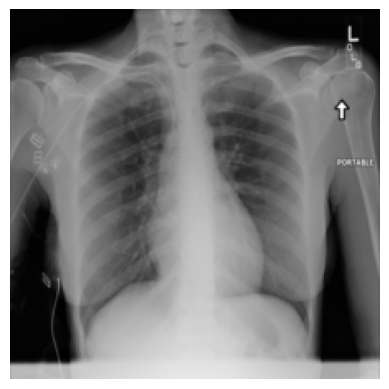

Bệnh có thật trong ảnh: ['No Finding']

Finding               Calibrated p  Threshold  Decision  
---------------------------------------------------------
Infiltration          0.0086        0.224      Negative  
Atelectasis           0.0018        0.235      Negative  
Consolidation         0.0015        0.148      Negative  
Effusion              0.0010        0.201      Negative  
Fibrosis              0.0010        0.072      Negative  
Pleural_Thickening    0.0009        0.150      Negative  
Pneumothorax          0.0009        0.142      Negative  
Mass                  0.0008        0.185      Negative  
Nodule                0.0006        0.204      Negative  
Pneumonia             0.0001        0.061      Negative  
Cardiomegaly          0.0001        0.188      Negative  
Edema                 0.0001        0.086      Negative  
Emphysema             0.0001        0.161      Negative  
Hernia                0.0000        0.035      Negative  

Research prototype, not for dia

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Cột path trỏ vào /kaggle/input/..., ảnh chỉ có sau khi tải bộ dữ liệu
kagglehub.dataset_download('khanfashee/nih-chest-x-ray-14-224x224-resized')
val = pd.read_csv(VAL_CSV)
row = val.sample(1, random_state=1).iloc[0]

plt.imshow(Image.open(row['path']), cmap='gray')
plt.axis('off')
plt.show()
print('Bệnh có thật trong ảnh:', [d for d in DISEASES if row[d] == 1] or ['No Finding'])
p_cal, positive = predict(row['path'], model)

## 4. (Tùy chọn) Dự đoán trên ảnh của bạn

Ảnh nên là X-quang ngực chụp thẳng. Ảnh CT, ảnh chụp nghiêng hoặc ảnh từ nguồn khác nằm ngoài dữ liệu huấn luyện, nên kết quả không có ý nghĩa.

In [ ]:
from google.colab import files

uploaded = files.upload()
print(predict(list(uploaded)[0], model)[0].round(3))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

import numpy as np
import pandas as pd

RUN_DIR = '/content/drive/MyDrive/CXR_Project/densenet121_baseline/'
DATA_DIR = '/content/drive/MyDrive/CXR_Project/data/'
OUT_DIR = '/content/drive/MyDrive/CXR_Project/results/figures/'
SPLIT = 'test'      # dùng 'val' để thử. Chỉ đổi sang 'test' khi kết quả cuối cùng đã chốt.

DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia',
]

# Ngưỡng của Khối D, chọn trên xác suất gốc sigmoid(z)
THRESHOLDS = {
    'Atelectasis': 0.235, 'Cardiomegaly': 0.188, 'Effusion': 0.201,
    'Infiltration': 0.224, 'Mass': 0.185, 'Nodule': 0.204,
    'Pneumonia': 0.061, 'Pneumothorax': 0.142, 'Consolidation': 0.148,
    'Edema': 0.086, 'Emphysema': 0.161, 'Fibrosis': 0.072,
    'Pleural_Thickening': 0.150, 'Hernia': 0.035,
}


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


os.makedirs(OUT_DIR, exist_ok=True)
logits = np.load(RUN_DIR + f'logits_{SPLIT}.npy').astype(np.float64)
labels = np.load(RUN_DIR + f'labels_{SPLIT}.npy').astype(int)
df = pd.read_csv(DATA_DIR + f'{SPLIT}.csv')

assert len(df) == len(logits) == len(labels), (len(df), len(logits), len(labels))
assert np.array_equal(df[DISEASES].to_numpy().astype(int), labels), 'CSV và file nhãn lệch thứ tự'

p_raw = sigmoid(logits)      # so ngưỡng với xác suất gốc
print(SPLIT, ':', len(df), 'ảnh')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
test : 25596 ảnh


In [ ]:
import glob

import kagglehub

root = kagglehub.dataset_download('khanfashee/nih-chest-x-ray-14-224x224-resized')
OLD_ROOT = '/kaggle/input/nih-chest-x-ray-14-224x224-resized'


def find_image(row):
    # Cột path trỏ vào /kaggle/input. Đổi sang nơi tải thật; nếu cấu trúc khác thì tìm theo tên file
    p = row['path'].replace(OLD_ROOT, root)
    if os.path.exists(p):
        return p
    hits = glob.glob(os.path.join(root, '**', row['image']), recursive=True)
    assert hits, f"Không tìm thấy {row['image']} trong {root}"
    return hits[0]

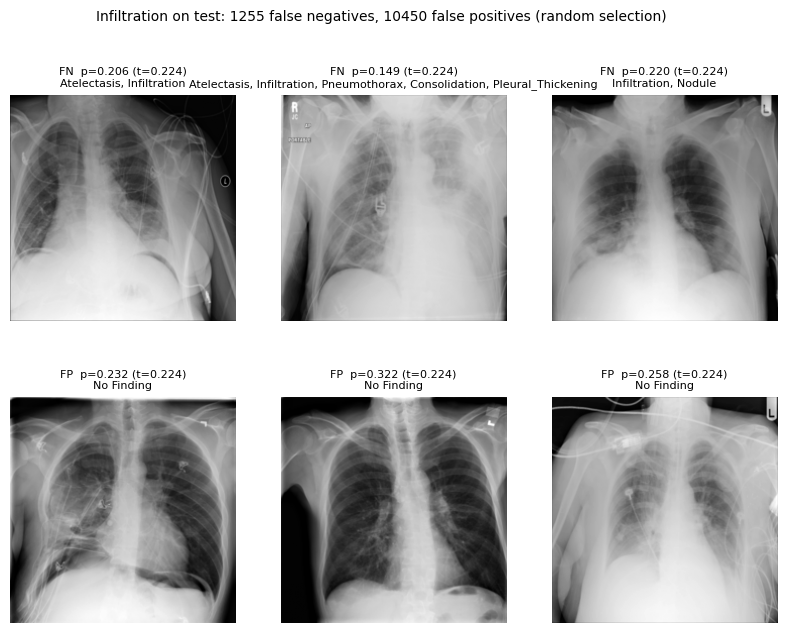

Đã lưu /content/drive/MyDrive/CXR_Project/results/figures/error_Infiltration_test_random.png


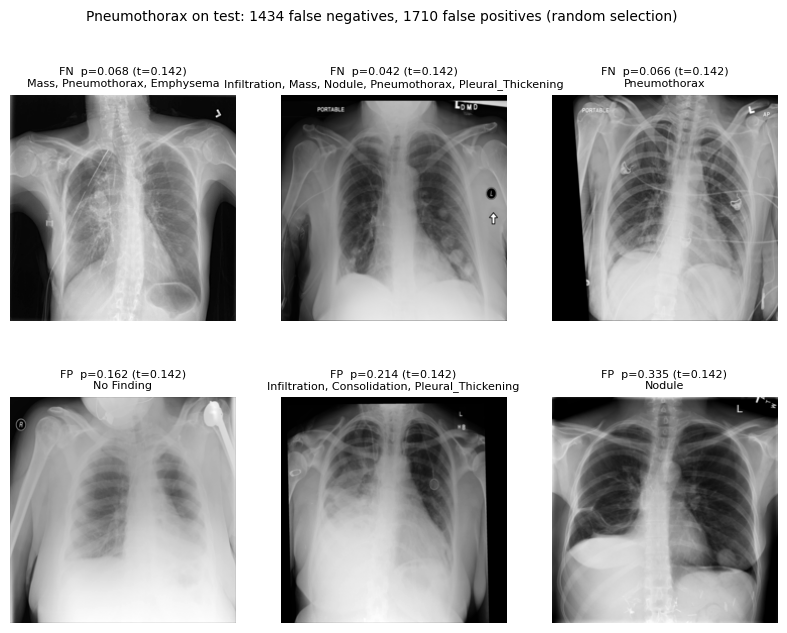

Đã lưu /content/drive/MyDrive/CXR_Project/results/figures/error_Pneumothorax_test_random.png


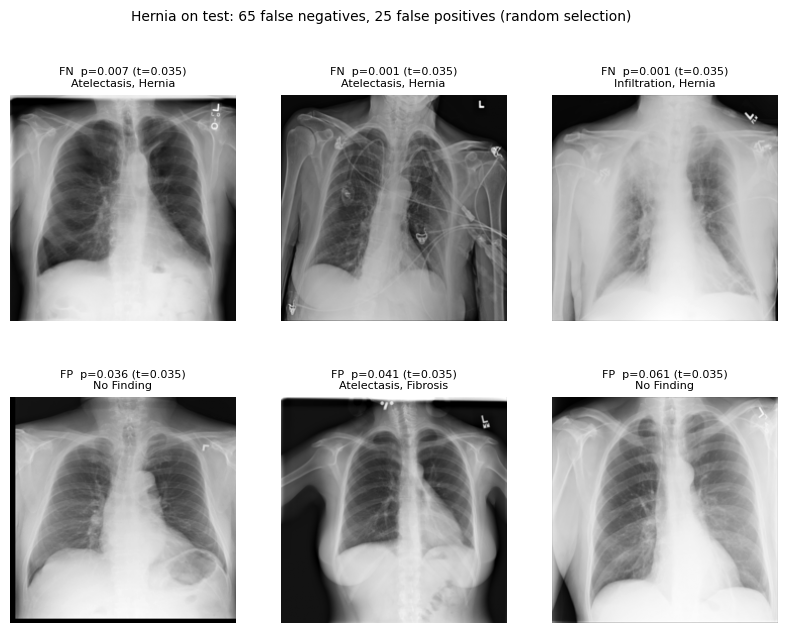

Đã lưu /content/drive/MyDrive/CXR_Project/results/figures/error_Hernia_test_random.png


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image


def pick_errors(disease, kind, n=3, how='random', seed=0):
    # kind: 'FN' (bỏ sót) hoặc 'FP' (báo nhầm). how: 'random' (ngẫu nhiên) hoặc 'confident' (sai chắc chắn nhất)
    c = DISEASES.index(disease)
    t = THRESHOLDS[disease]
    p, y = p_raw[:, c], labels[:, c]
    if kind == 'FN':
        mask, score = (y == 1) & (p < t), p        # p càng nhỏ thì bỏ sót càng chắc chắn
    else:
        mask, score = (y == 0) & (p >= t), -p      # p càng lớn thì báo nhầm càng chắc chắn
    idx = np.flatnonzero(mask)
    if how == 'random':
        chosen = np.random.default_rng(seed).permutation(idx)[:n]
    else:
        chosen = idx[np.argsort(score[idx])][:n]
    return chosen, int(mask.sum())


def error_grid(disease, n=3, how='random', seed=0):
    c = DISEASES.index(disease)
    fn_idx, n_fn = pick_errors(disease, 'FN', n, how, seed)
    fp_idx, n_fp = pick_errors(disease, 'FP', n, how, seed)
    fig, axes = plt.subplots(2, n, figsize=(3.3 * n, 7.2))
    for r, (tag, idxs) in enumerate([('FN', fn_idx), ('FP', fp_idx)]):
        for k in range(n):
            ax = axes[r, k]
            ax.axis('off')
            if k < len(idxs):
                i = idxs[k]
                row = df.iloc[i]
                ax.imshow(Image.open(find_image(row)), cmap='gray')
                true = [d for d in DISEASES if row[d] == 1] or ['No Finding']
                ax.set_title(f"{tag}  p={p_raw[i, c]:.3f} (t={THRESHOLDS[disease]:.3f})\n" + ', '.join(true), fontsize=8)
    fig.suptitle(f'{disease} on {SPLIT}: {n_fn} false negatives, {n_fp} false positives ({how} selection)', fontsize=10)
    out = OUT_DIR + f'error_{disease}_{SPLIT}_{how}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Đã lưu', out)


for d in ['Infiltration', 'Pneumothorax', 'Hernia']:
    error_grid(d, n=3, how='random')